<a href="https://colab.research.google.com/github/ZackyRioOrlando/Praktikum-Pembelajaran-Mesin-/blob/main/JS05/JS05_Tugas_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Langkah 1: Load Data

In [1]:
from google.colab import files

uploaded = files.upload()

Saving voice.csv to voice.csv


Langkah 2: Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Langkah 3: Membaca Dataset

In [56]:
df = pd.read_csv("voice.csv")
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


Langkah 4: Melihat Informasi Data

In [57]:
print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", df.shape[1] - 1)

print("\nJumlah masing-masing label:")
print(df["label"].value_counts())

print("\nInformasi dataset:")
print(df.info())

Jumlah data: 3168
Jumlah fitur: 20

Jumlah masing-masing label:
label
male      1584
female    1584
Name: count, dtype: int64

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  m

Langkah 5: Memisahkan Fitur dan Label

In [58]:
# X = fitur
X = df.drop("label", axis=1)

# y = label
y = df["label"]

Langkah 6: Membagi Data Train dan Data Test

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

Jumlah data training: 2534
Jumlah data testing : 634


Langkah 7: Melakukan Standarisasi


In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.

Langkah 8: Membuat Model kNN

In [61]:
	# Tentukan nilai K
	knn = KNeighborsClassifier(n_neighbors=3)

	# Latih model
	knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

Langkah 9: Melakukan Prediksi

In [62]:
y_pred = knn.predict(X_test_scaled)

print("Hasil prediksi:")
print(y_pred[:20])

Hasil prediksi:
['female' 'male' 'male' 'female' 'female' 'female' 'male' 'male' 'female'
 'male' 'female' 'female' 'female' 'female' 'female' 'female' 'female'
 'female' 'female' 'male']


Langkah 10: Mengukur Akurasi

In [63]:
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi model kNN:", accuracy)
print("Akurasi model kNN: {:.2f}%".format(accuracy * 100))

Akurasi model kNN: 0.9810725552050473
Akurasi model kNN: 98.11%


Langkah 11: Confusion Matriks

In [64]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

Confusion Matrix:
[[290   7]
 [  5 332]]
Akurasi: 0.9810725552050473
Confusion Matrix:
 [[290   7]
 [  5 332]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.98      0.98       297
        male       0.98      0.99      0.98       337

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



Langkah 12: Evaluasi Nilai k

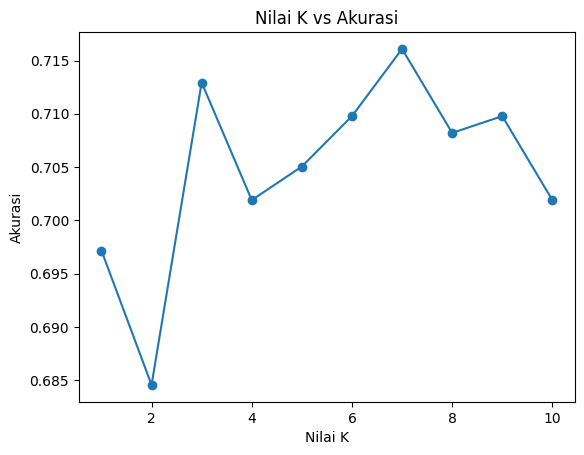

In [65]:
	acc = []
	for k in range(1, 11):
	    model = KNeighborsClassifier(n_neighbors=k)
	    model.fit(X_train, y_train)
	    acc.append(model.score(X_test, y_test))

	plt.plot(range(1, 11), acc, marker='o')
	plt.title('Nilai K vs Akurasi')
	plt.xlabel('Nilai K')
	plt.ylabel('Akurasi')
	plt.show()


Model klasifikasi menggunakan algoritma kNN dengan k=3 berhasil mengklasifikasikan jenis suara male dan female. Setelah dilakukan standardisasi fitur dan pembagian data sebesar 80% untuk training dan 20% untuk testing, model memperoleh akurasi sekitar 98.11% pada data testing.

# 2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

Langkah 1: Import Data

In [67]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


Langkah 2: Pilih Fitur Terbaik

In [68]:
selector = SelectKBest(score_func=f_classif, k=3)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

Langkah 3: Lihat Fitur yang Terpilih

In [69]:
fitur_terpilih = X.columns[selector.get_support()]

print("Fitur yang digunakan:")
for fitur in fitur_terpilih:
    print(fitur)

Fitur yang digunakan:
Q25
IQR
meanfun


Berdasarkan percobaan seleksi fitur menggunakan SelectKBest dengan f_classif dan k=3, diperoleh tiga fitur yang digunakan untuk klasifikasi suara male dan female, yaitu Q25, IQR, dan meanfun.

# 3.Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai k yang terbaik? Lampirkan grafika analisis dan alasan Anda

Langkah 1: Melakukan Normalisasi Fitur

In [70]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

Langkah 2: Mencoba Beberapa Nilai k

In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

nilai_k = range(1, 21)
akurasi = []

for k in nilai_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    akurasi.append(acc)

for k, acc in zip(nilai_k, akurasi):
    print(f"k = {k}, Akurasi = {acc:.4f}")

k = 1, Akurasi = 0.9669
k = 2, Akurasi = 0.9653
k = 3, Akurasi = 0.9779
k = 4, Akurasi = 0.9716
k = 5, Akurasi = 0.9795
k = 6, Akurasi = 0.9732
k = 7, Akurasi = 0.9779
k = 8, Akurasi = 0.9716
k = 9, Akurasi = 0.9779
k = 10, Akurasi = 0.9748
k = 11, Akurasi = 0.9779
k = 12, Akurasi = 0.9748
k = 13, Akurasi = 0.9763
k = 14, Akurasi = 0.9779
k = 15, Akurasi = 0.9779
k = 16, Akurasi = 0.9795
k = 17, Akurasi = 0.9795
k = 18, Akurasi = 0.9779
k = 19, Akurasi = 0.9779
k = 20, Akurasi = 0.9779


Langkah 3: Mencari Nilai k dengan Akurasi Tertinggi

In [72]:
k_terbaik = nilai_k[akurasi.index(max(akurasi))]
akurasi_terbaik = max(akurasi)

print("Nilai k terbaik:", k_terbaik)
print("Akurasi terbaik:", akurasi_terbaik)

Nilai k terbaik: 5
Akurasi terbaik: 0.9794952681388013


Langkah 4: Membuat Grafik

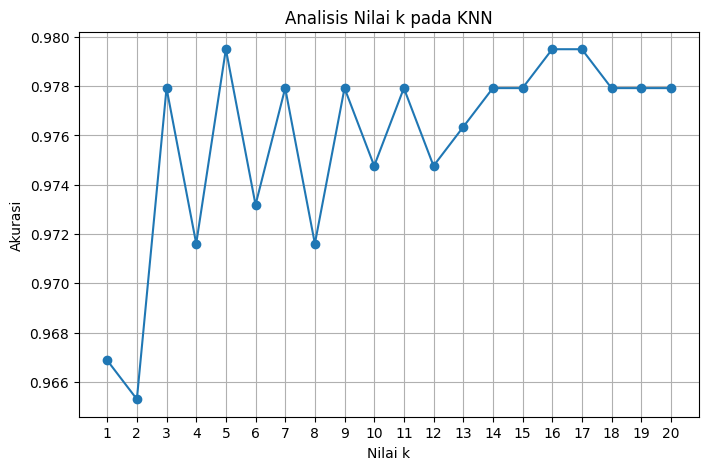

In [73]:
plt.figure(figsize=(8, 5))

plt.plot(nilai_k, akurasi, marker='o')

plt.xlabel("Nilai k")
plt.ylabel("Akurasi")
plt.title("Analisis Nilai k pada KNN")
plt.xticks(list(nilai_k))
plt.grid()

plt.show()

Berdasarkan fitur yang telah dipilih pada soal nomor 2, yaitu Q25, IQR, dan meanfun, dilakukan percobaan menggunakan beberapa nilai k pada algoritma KNN. Berdasarkan hasil pengujian, nilai akurasi tertinggi adalah 0,9795 atau 97,95%. Nilai tersebut diperoleh pada k = 5, 16, dan 17. Karena k = 5 merupakan nilai k terkecil yang menghasilkan akurasi tertinggi, maka k = 5 digunakan sebagai nilai k terbaik.